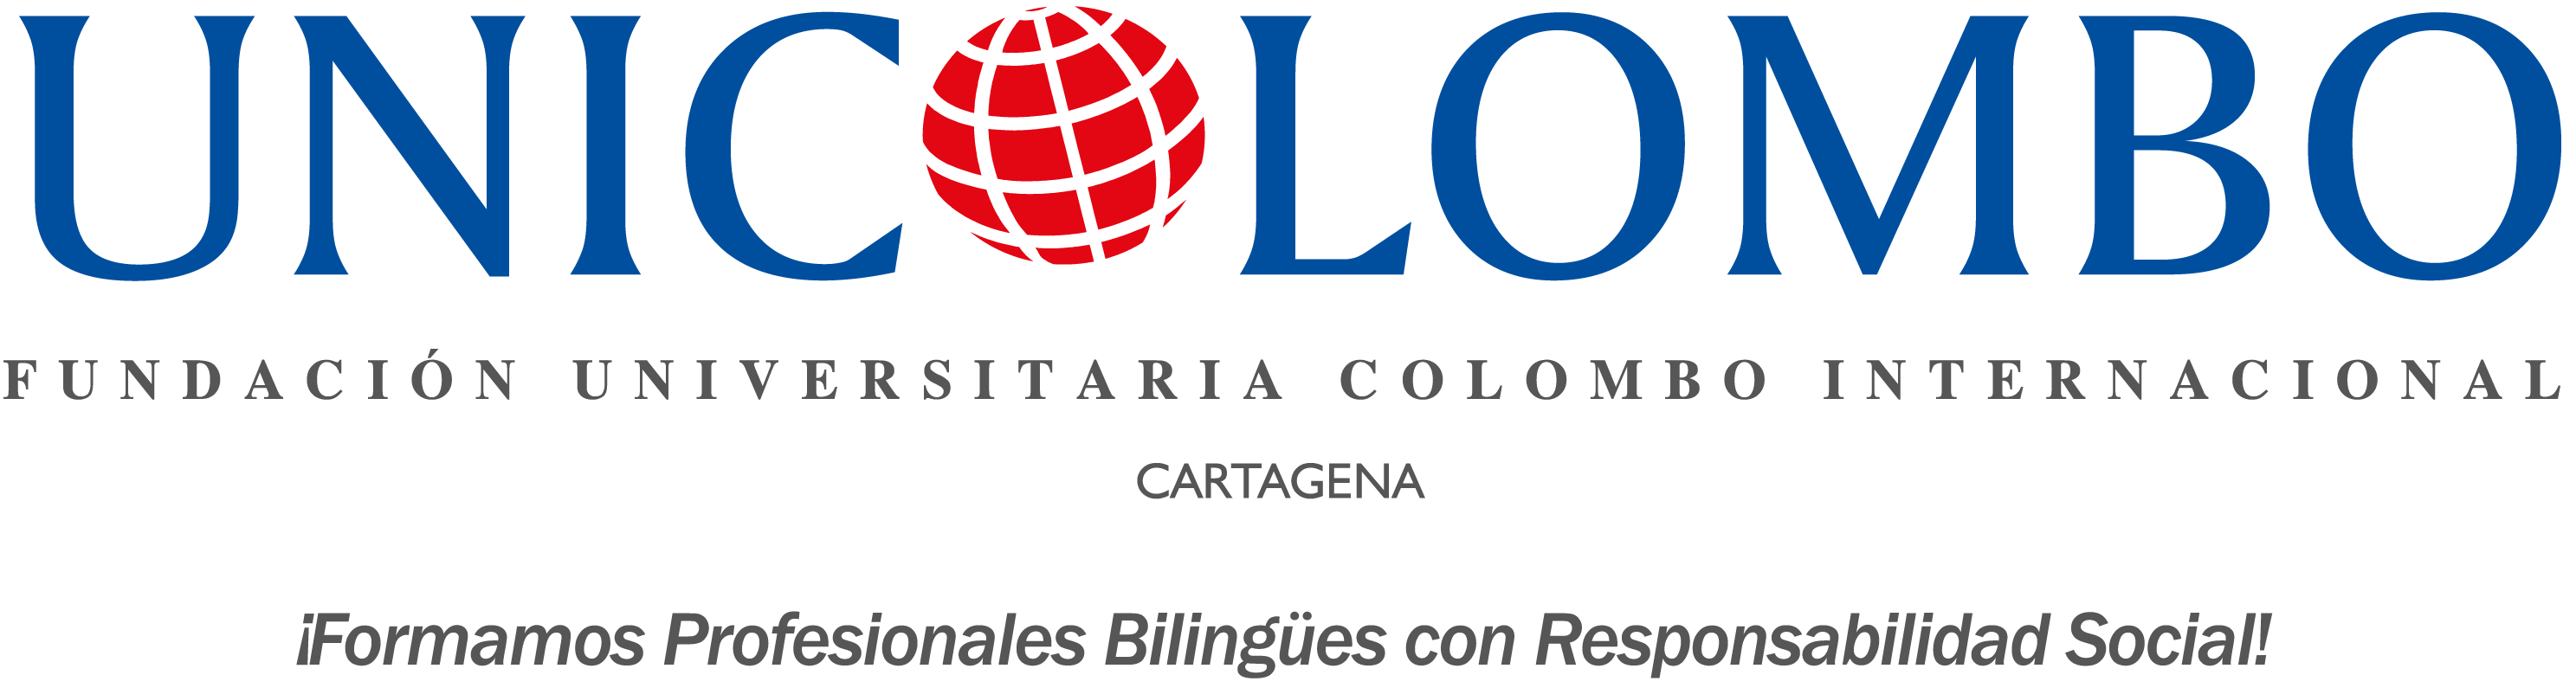

# Diplomado de Grado en Análisis de Datos Aplicado a la Toma de Decisiones
## UNICOLOMBO — Fundación Universitaria Colombo Internacional · Cartagena
**Módulo 2:** Preparación y Análisis Exploratorio de Datos  
**Sesión 1:** Diagnóstico y Calidad de Datos  
**Docente:** Ing. Heyder Medrano Olier  
**Período:** 2026 — Vacaciones

---
**Tipo:** Notebook de Actividad (trabajo del estudiante)  
**Entrega:** 27 de junio de 2026 · 23:59 (hora Colombia)  
**Valor:** 5.0 puntos  

> ⚠️ **Antes de entregar:** Ejecute *Kernel → Restart & Run All* para confirmar que todo corre sin errores.

**Estudiante:** [Jefferson Arrieta Duran]  
**Fecha de ejecución:** [24/06/2026]

## Contexto

El CTO de **DataRetail LATAM S.A.S.** le ha encargado auditar la calidad de los datos de ventas. Usará el mismo dataset sintético visto en clase. Su análisis determinará si los datos son confiables para tomar decisiones presupuestarias del próximo trimestre.

## Parte 1 — Configuración

In [ ]:
# Instalar si es necesario: !pip install ydata-profiling dtale missingno scipy
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import missingno as msno, scipy.stats as stats, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
print('✅ Librerías listas')

## Parte 2 — Generación del Dataset

Ejecute esta celda sin modificar. Genera el dataset DataRetail LATAM con problemas de calidad intencionales.

In [ ]:
import numpy as np, pandas as pd, random
from datetime import datetime, timedelta

np.random.seed(42); random.seed(42)
N = 2000

ciudades = ['Bogotá','Medellín','Cali','Barranquilla','Cartagena',
            'Lima','Ciudad de México','Buenos Aires','Santiago','Montevideo']
# Versiones con inconsistencias intencionales
ciudades_sucias = ciudades + ['bogota','BOGOTÁ','Medellin','cali ','barranquilla',
                               'Ciudad de mexico','buenos aires','SANTIAGO']
paises   = ['Colombia','Perú','México','Argentina','Chile','Uruguay']
categorias = ['Computación','Periféricos','Audio','Telefonía','Accesorios','Gaming','Componentes']
canales  = ['Tienda Física','E-commerce','Distribuidor','Corporativo','Marketplace']
# Versiones sucias de canal
canales_sucios = canales + ['tienda fisica','E-Comerce','distribuidor ','CORPORATIVO']
productos = ['Laptop Pro','Tablet Ultra','Monitor 4K','Teclado Inalámbrico',
             'Auriculares BT','Parlante Portátil','Smartphone Galaxy',
             'Cámara Web HD','Smartwatch Pro','Mouse Gaming','SSD 1TB','GPU RTX 4060']
precios_base = {'Laptop Pro':1200,'Tablet Ultra':450,'Monitor 4K':380,
                'Teclado Inalámbrico':75,'Auriculares BT':120,'Parlante Portátil':90,
                'Smartphone Galaxy':680,'Cámara Web HD':95,'Smartwatch Pro':250,
                'Mouse Gaming':65,'SSD 1TB':130,'GPU RTX 4060':580}

rows = []
for i in range(N):
    prod  = random.choice(productos)
    cat   = categorias[productos.index(prod) % len(categorias)]
    pais  = random.choice(paises)
    # ciudad con inconsistencias (15% de registros)
    if random.random() < 0.15:
        ciudad = random.choice(ciudades_sucias)
    else:
        ciudad = random.choice(ciudades)
    # canal con inconsistencias (10% de registros)
    canal = random.choice(canales_sucios) if random.random() < 0.10 else random.choice(canales)
    qty   = random.randint(1, 20)
    precio= round(precios_base[prod] * np.random.uniform(0.8,1.3), 2)
    desc  = round(random.choice([0,0,0,0.05,0.10,0.15,0.20,0.30,
                                  0.35,0.50]), 2)  # algunos > 30% (violación)
    total = round(qty * precio * (1 - desc), 2)
    margen= round(total * np.random.uniform(-0.05, 0.35), 2)
    fecha = datetime(2024,1,1) + timedelta(days=random.randint(0,729))
    rows.append({
        'id_venta':       f'V{i+1:05d}',
        'fecha_venta':    fecha.strftime('%Y-%m-%d'),
        'id_cliente':     f'C{random.randint(1,500):04d}',
        'nombre_cliente': f'Cliente {random.randint(1,500)}',
        'ciudad':         ciudad,
        'pais':           pais,
        'id_producto':    f'P{productos.index(prod)+1:02d}',
        'nombre_producto':prod,
        'categoria':      cat,
        'canal_venta':    canal,
        'cantidad':       qty,
        'precio_unitario':precio,
        'descuento':      desc,
        'total_venta':    total,
        'margen_utilidad':margen,
    })

df_raw = pd.DataFrame(rows)

# ── Introducir problemas de calidad intencionales ──────────────────────────
# 1. Nulos (~6% en precio_unitario, ~4% en total_venta, ~3% en margen_utilidad)
idx_p = np.random.choice(df_raw.index, size=int(N*0.06), replace=False)
idx_t = np.random.choice(df_raw.index, size=int(N*0.04), replace=False)
idx_m = np.random.choice(df_raw.index, size=int(N*0.03), replace=False)
df_raw.loc[idx_p, 'precio_unitario'] = np.nan
df_raw.loc[idx_t, 'total_venta']     = np.nan
df_raw.loc[idx_m, 'margen_utilidad'] = np.nan

# 2. Duplicados (40 filas repetidas)
dup_idx = np.random.choice(df_raw.index, size=40, replace=False)
duplicados = df_raw.loc[dup_idx].copy()
df_raw = pd.concat([df_raw, duplicados], ignore_index=True)

# 3. Outliers extremos en total_venta (10 registros con valores irreales)
out_idx = np.random.choice(df_raw.index, size=10, replace=False)
df_raw.loc[out_idx, 'total_venta'] = np.random.uniform(50000, 200000, 10)

# 4. precio_unitario como string en 20 registros (tipo incorrecto)
str_idx = np.random.choice(df_raw.index, size=20, replace=False)
df_raw['precio_unitario'] = df_raw['precio_unitario'].astype(object)
df_raw.loc[str_idx, 'precio_unitario'] = df_raw.loc[str_idx,'precio_unitario'].apply(
    lambda x: f'${x}' if pd.notna(x) else x)

df_raw = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Dataset DataRetail LATAM generado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"   Problemas intencionales: nulos, duplicados, outliers, tipos incorrectos, inconsistencias")
df_raw.head(5)


## Parte 3 — Carga y Preparación

Cree la copia de trabajo `df` y convierta los tipos de datos necesarios. Recuerde que `precio_unitario` tiene valores con formato string que deben convertirse.

In [ ]:
# Complete el código
df = df_raw.copy()
# Convertir fecha_venta a datetime
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'], errors='coerce')
# Convertir precio_unitario a numérico (limpiar el '$' primero)
df['precio_unitario'] = pd.to_numeric(
    df['precio_unitario'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
# Su código: verifique el rango de fechas
print(f'Fechas: {df.fecha_venta.min().date()} → {df.fecha_venta.max().date()}')
df.head(5)

## Parte 4 — Perfil Automático (ydata-profiling)

Genere el reporte de perfil. Identifique las alertas más importantes en el reporte.

In [ ]:
!pip install ydata-profiling


In [ ]:
# ydata-profiling genera un reporte HTML interactivo completo
# Si no está instalado: !pip install ydata-profiling
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(
        df,
        title="DataRetail LATAM S01 — Reporte de Calidad",
        explorative=True,
        minimal=False,
        correlations={"auto": {"calculate": True}},
        missing_diagrams={"bar": True, "matrix": True, "heatmap": True},
    )
    profile.to_notebook_iframe()
except ImportError:
    print("Instale ydata-profiling: !pip install ydata-profiling")
    print("Continuando con análisis manual...")

# Después del perfil, anote las 3 alertas más importantes:
# 1. El dataset presenta 39 filas duplicadas (1.9 %), lo que puede generar
#    un conteo incorrecto de registros y afectar los resultados del análisis.

# 2. La variable descuento contiene 620 valores iguales a cero (30.4 %),
#    lo que podría indicar promociones inexistentes, errores de captura
#    o una concentración importante de ventas sin descuento.

# 3. Las variables precio_unitario, total_venta y margen_utilidad presentan
#    valores faltantes, lo que puede afectar los cálculos financieros y la
#    calidad de los análisis posteriores.

Se logra apreciar el reporte generado al instalar ydata-profiling el cual nos ayuda a entender mejor cada variable y cada una de sus relaciones

## Parte 5 — Análisis Estructural

Use `df.info()` y construya la tabla de inventario de variables.

In [ ]:
# Información estructural
df.info(memory_usage='deep')

# Tabla de inventario
inventario = pd.DataFrame({
    'Tipo_Pandas':  df.dtypes,
    'No_Nulos':     df.notna().sum(),
    'Nulos':        df.isna().sum(),
    '% Nulos':      (df.isna().mean()*100).round(2),
    'Cardinalidad': df.nunique(),
})
print(inventario.to_string())

## Parte 6 — Estadísticas Descriptivas

Genere estadísticas extendidas (percentiles 5, 25, 50, 75, 95) y calcule la asimetría de cada variable numérica. Identifique las distribuciones más sesgadas.

In [ ]:
cols_num = ['cantidad','precio_unitario','descuento','total_venta','margen_utilidad']
# Estadísticas extendidas
desc = df[cols_num].describe(percentiles=[.05,.25,.50,.75,.95])
print(desc.T.to_string())

# Asimetría
print('\nASIMETRÍA (skewness):')
for col in cols_num:
    sk = df[col].skew()
    flag = '⚠' if abs(sk) > 1 else '✅'
    print(f'{flag} {col:20s}: {sk:.4f}')

### 📝 Observaciones — Estadísticas

> Escriba aquí sus observaciones:

- Variable con mayor asimetría: [total_venta] (12.61), indicando una distribución fuertemente sesgada hacia la derecha.
- Rango de `descuento`: min=[ 0.00 ] max=[ 0.50 ] — ¿Hay valores fuera del 30%?
     R// Sí existen valores fuera del 30 %, ya que el descuento máximo corresponde al 50 %, por lo que estos registros deben validarse.
- Rango de `total_venta`: min=[ 37.30 ] max=[ 183611.84 ] — ¿Hay valores sospechosos?
     
     R//Se identifican valores extremadamente altos en comparación con la mediana (689.98), lo que sugiere la existencia de valores atípicos que podrían influir significativamente en los análisis estadísticos.

## Parte 7 — Análisis de Valores Nulos

Cuantifique los nulos por columna y genere los **3 gráficos de missingno** (matrix, bar, heatmap). Clasifique el mecanismo de cada columna con nulos.

In [ ]:
# Cuantificación
nulos = df.isna().sum().sort_values(ascending=False)
pct   = (df.isna().mean()*100).sort_values(ascending=False)
tabla = pd.DataFrame({'Nulos': nulos, '% Nulos': pct.round(2), 'Completitud%': (100-pct).round(2)})
print('NULOS POR COLUMNA:')
print(tabla[tabla['Nulos']>0].to_string())

In [ ]:
# 3 gráficos missingno
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Datos Faltantes — DataRetail LATAM S01', fontsize=13, fontweight='bold')
msno.matrix(df, ax=axes[0], fontsize=9)
axes[0].set_title('Matrix (patrón)', fontweight='bold')
msno.bar(df, ax=axes[1], color='steelblue', fontsize=9)
axes[1].set_title('Bar (completitud)', fontweight='bold')
msno.heatmap(df, ax=axes[2], fontsize=9)
axes[2].set_title('Heatmap (correlación nulos)', fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Clasificación de Mecanismos de Nulos

> Clasifique cada columna con nulos:

| Columna         | % Nulos | Mecanismo | Justificación                                                                                                                                          |
| --------------- | ------: | --------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| precio_unitario |   6.08 % | MAR       | La ausencia del precio puede estar relacionada con el tipo de producto, la categoría o errores durante el registro de ciertos artículos.               |
| total_venta     |   3.92 % | MAR       | Los valores faltantes pueden depender de otras variables, como la cantidad vendida o el precio unitario, ya que el total se calcula a partir de ellas. |
| margen_utilidad |   3.04 % | MAR       | La falta de datos puede estar asociada a la ausencia del precio o del total de venta, dado que el margen depende de estas variables.                   |


## Parte 8 — Detección de Duplicados

Analice duplicados exactos y por `id_venta`. Muestre ejemplos.

In [ ]:
n_dup_exacto = df.duplicated().sum()
n_dup_id     = df.duplicated(subset=['id_venta']).sum()

print(f'Registros totales:      {len(df):,}')
print(f'Duplicados exactos:     {n_dup_exacto:,} ({n_dup_exacto/len(df)*100:.2f}%)')
print(f'Duplicados id_venta:    {n_dup_id:,} ({n_dup_id/len(df)*100:.2f}%)')

if n_dup_exacto > 0:
    print('\nEjemplos:')
    mask = df.duplicated(keep=False)
    print(df[mask].sort_values('id_venta')[['id_venta','fecha_venta','nombre_producto','total_venta']].head(6).to_string())

## Parte 9 — Outliers con IQR y Z-score

In [ ]:
# Tabla IQR
resultados_iqr = []
for col in cols_num:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(.25), s.quantile(.75)
    IQR = Q3-Q1
    n_out = ((s < Q1-1.5*IQR)|(s > Q3+1.5*IQR)).sum()
    resultados_iqr.append({'Variable':col,'Q1':round(Q1,2),'Q3':round(Q3,2),
                           'IQR':round(IQR,2),'Outliers':n_out,'%':round(n_out/len(s)*100,2)})
print('TABLA IQR:')
print(pd.DataFrame(resultados_iqr).to_string(index=False))

In [ ]:
# Boxplots
fig, axes = plt.subplots(1, len(cols_num), figsize=(18, 5))
fig.suptitle('Outliers por Método IQR — DataRetail LATAM S01', fontsize=13, fontweight='bold')
for ax, col, c in zip(axes, cols_num, sns.color_palette('Set2',5)):
    s = df[col].dropna()
    Q1,Q3 = s.quantile(.25),s.quantile(.75)
    n_out = ((s < Q1-1.5*(Q3-Q1))|(s > Q3+1.5*(Q3-Q1))).sum()
    ax.boxplot(s, patch_artist=True, boxprops=dict(facecolor=c,alpha=0.7),
               medianprops=dict(color='black',linewidth=2))
    ax.set_title(f'{col}\n{n_out} outliers', fontweight='bold', fontsize=10)
    ax.tick_params(labelbottom=False)
plt.tight_layout(); plt.show()

In [ ]:
# Z-score
print('OUTLIERS Z-SCORE (|Z|>3):')
for col in cols_num:
    s = df[col].dropna()
    z = np.abs(stats.zscore(s))
    print(f'  {col:20s}: {(z>3).sum():4d} outliers | máx valor = {s.max():,.2f}')

### 📝 Clasificación de Outliers

> Para cada variable, clasifique los outliers:
| Variable            | N° Outliers IQR | Clasificación | Justificación                                                                                                                           |
| ------------------- | --------------: | ------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **cantidad**        |               0 | Sin outliers  | No se detectaron valores atípicos. La distribución de la variable es estable y los datos se encuentran dentro de los límites esperados. |
| **precio_unitario** |              98 | Moderados     | El 5.11 % de los registros se consideran atípicos. Existen precios significativamente mayores que la mayoría de los productos.          |
| **total_venta**     |             160 | Altos         | El 8.16 % de los registros son outliers, indicando ventas excepcionalmente elevadas respecto al comportamiento general de los datos.    |
| **descuento**       |               0 | Sin outliers  | Los descuentos se encuentran dentro de los límites establecidos por el método IQR, sin valores atípicos detectados.                     |
| **margen_utilidad** |             211 | Altos         | Presenta el mayor porcentaje de outliers (10.67 %), evidenciando utilidades muy superiores o inferiores al comportamiento habitual.     |


## Parte 10 — Inconsistencias Categóricas

In [ ]:
cols_cat = ['ciudad','pais','categoria','canal_venta']
for col in cols_cat:
    vals = df[col].dropna()
    n_real  = vals.nunique()
    n_norm  = len(set(vals.str.strip().str.lower()))
    n_esp   = (vals != vals.str.strip()).sum()
    estado  = '⚠' if n_real > n_norm or n_esp > 0 else '✅'
    print(f'{estado} {col}: {n_real} únicos reales → {n_norm} normalizados | {n_esp} con espacios')
    if n_real > n_norm:
        print(f'   Muestra de valores:')
        print(f'   {list(vals.unique()[:8])}')
    print()

## Parte 11 — Validación de Dominio

In [ ]:
reglas = [
    ('descuento <= 0.30',  df['descuento'] > 0.30),
    ('precio_unitario > 0', df['precio_unitario'] <= 0),
    ('total_venta > 0',    df['total_venta'] <= 0),
    ('cantidad >= 1',      df['cantidad'] < 1),
    ('fecha 2024-2025',    ~df['fecha_venta'].between('2024-01-01','2025-12-31')),
]
print('VALIDACIÓN DE REGLAS DE NEGOCIO:')
print('='*55)
for regla, cond in reglas:
    try:
        n = cond.sum()
        estado = '⚠️' if n > 0 else '✅'
        print(f'{estado} {regla:30s}: {n:,} violaciones ({n/len(df)*100:.2f}%)')
    except Exception as e:
        print(f'  Error en {regla}: {e}')

| Hallazgo                                    | Descripción                                                                                                                             | Impacto                                                                                   |
| ------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| Descuentos superiores al 30 %               | Se identificaron registros con descuentos de hasta 50 %, superando el límite de negocio establecido del 30 %.                           | Puede indicar promociones especiales o errores de captura de datos.                       |
| Márgenes de utilidad negativos              | La variable `margen_utilidad` presenta valores mínimos de -673.98.                                                                      | Indica posibles pérdidas en algunas ventas o inconsistencias en los cálculos financieros. |
| Variantes de texto en variables categóricas | Las columnas `ciudad`, `pais`, `categoria` y `canal_venta` pueden contener diferencias de mayúsculas, espacios o formatos de escritura. | Genera categorías duplicadas y afecta los análisis de frecuencia y segmentación.          |


## Parte 12 — Panel Visual de Calidad

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel de Diagnóstico — DataRetail LATAM S01', fontsize=14, fontweight='bold')

# 1. Nulos por columna
pct_n = df.isna().mean()*100
pct_n = pct_n[pct_n>0].sort_values()
if len(pct_n):
    pct_n.plot(kind='barh', ax=axes[0,0], color='#e15759')
    axes[0,0].set_title('% Nulos por Columna', fontweight='bold')
    axes[0,0].axvline(5, color='navy', linestyle='--')

# 2. Boxplot total_venta
axes[0,1].boxplot(df['total_venta'].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#4e79a7',alpha=0.7),
                   medianprops=dict(color='red',linewidth=2))
axes[0,1].set_title('Outliers total_venta', fontweight='bold')

# 3. Distribución descuento
df['descuento'].dropna().hist(ax=axes[1,0], bins=20, color='#59a14f', edgecolor='white')
axes[1,0].axvline(0.30, color='red', linestyle='--', label='Límite 30%')
axes[1,0].set_title('Distribución Descuento', fontweight='bold')
axes[1,0].legend()

# 4. Canal de venta
df['canal_venta'].value_counts().plot(kind='bar', ax=axes[1,1], color='#af7aa1', edgecolor='white')
axes[1,1].set_title('Registros por Canal', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Parte 13 — Score de Calidad y Reporte Final

Calcule el score de calidad y construya el reporte diagnóstico para el CTO.

In [ ]:
# Score de calidad
pct_nulos_g  = df.isna().mean().mean()*100
pct_dup      = df.duplicated().mean()*100
s_tv = df['total_venta'].dropna()
Q1,Q3 = s_tv.quantile(.25), s_tv.quantile(.75)
pct_out      = ((s_tv < Q1-1.5*(Q3-Q1))|(s_tv > Q3+1.5*(Q3-Q1))).mean()*100
pct_desc_viol= (df['descuento'] > 0.30).mean()*100

score = 100
score -= min(pct_nulos_g * 3, 30)
score -= min(pct_dup * 5, 20)
score -= min(pct_out * 1.5, 15)
score -= min(pct_desc_viol * 2, 10)
nivel = '🔴 CRÍTICO' if score<60 else ('🟠 BAJO' if score<75 else ('🟡 ACEPTABLE' if score<90 else '🟢 BUENO'))

print('='*60)
print('  REPORTE DIAGNÓSTICO — DataRetail LATAM S01')
print('='*60)
print(f'  % Nulos globales:        {pct_nulos_g:.2f}%')
print(f'  % Duplicados:            {pct_dup:.2f}%')
print(f'  % Outliers total_venta:  {pct_out:.2f}%')
print(f'  % Violac. descuento:     {pct_desc_viol:.2f}%')
print(f'  SCORE:  {score:.1f}/100  {nivel}')
print('='*60)

El análisis de calidad del dataset permitió identificar tres problemas críticos que afectan la confiabilidad de la información. En primer lugar, el 20.34 % de los registros presenta descuentos superiores al 30 %, incumpliendo las reglas del negocio y pudiendo generar interpretaciones erróneas sobre las estrategias comerciales y promocionales. En segundo lugar, la variable total_venta presenta un 8.16 % de valores atípicos, con montos extremadamente altos que pueden distorsionar los indicadores financieros, las proyecciones y las medidas estadísticas. Finalmente, se encontraron valores faltantes en variables clave como precio_unitario, total_venta y margen_utilidad, lo que puede afectar la precisión de los análisis económicos y la toma de decisiones. Estos problemas reducen la calidad general del conjunto de datos, reflejada en un score de 65.6/100, clasificado como nivel bajo, por lo que se recomienda realizar procesos de limpieza, validación y estandarización antes de utilizar la información para el análisis de negocio.

### 📝 Plan de Acción para S02

> Complete la tabla con sus hallazgos reales:
| Prioridad | Problema            | Columnas                                      | Acción en S02                                                                           |
| --------- | ------------------- | --------------------------------------------- | --------------------------------------------------------------------------------------- |
| 1         | Nulos MAR          | precio_unitario                               | Imputar valores mediante mediana o categorias.                |
| 2         | Nulos MAR           | total_venta, margen_utilidad                  | Reconstruir valores utilizando variables relacionadas o aplicar técnicas de imputación. |
| 3         | Duplicados          | id_venta                                      | `drop_duplicates()`                                                                     |
| 4         | Outliers extremos   | total_venta, margen_utilidad, precio_unitario | Aplicar tratamiento IQR, winsorización o análisis de casos extremos.                    |
| 5         | Inconsistencias     | ciudad, canal_venta                           | `str.strip().str.title()`                                                               |
| 6         | Violaciones dominio | descuento                                     | Limitar valores máximos a 0.30 o validar registros excepcionales.                       |

### 💡 Insights de Negocio (mínimo 3)


1. Descuentos fuera de política comercial

   Más del 20 % de las transacciones presentan descuentos superiores al 30 %, lo que puede indicar incumplimiento de las políticas comerciales o campañas promocionales no controladas, afectando directamente la rentabilidad.

2. Concentración de ventas extraordinarias

   La variable total_venta presenta ventas excepcionalmente altas que generan una fuerte asimetría en los ingresos. Esto sugiere la existencia de clientes de alto valor o transacciones atípicas que deben analizarse individualmente.

3. Riesgo en los indicadores financieros

   Los valores faltantes en precio_unitario, total_venta y margen_utilidad pueden afectar la precisión de los indicadores financieros y generar decisiones incorrectas en procesos de planeación y análisis del negocio.

Estos hallazgos proporcionan una base sólida para las actividades de limpieza y preparación de datos que se realizarán en la Sesión 2.

## Referencias

1. McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly Media.
2. Little, R. & Rubin, D. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). Wiley.
3. Bilogur, A. (2023). missingno. https://github.com/ResidentMario/missingno
4. VanderPlas, J. (2023). *Python Data Science Handbook*. O'Reilly.
5. ydata-profiling (2024). https://docs.profiling.ydata.ai

---
*Notebook Actividad S01 — Diplomado de Grado en Análisis de Datos Aplicado a la Toma de Decisiones  
UNICOLOMBO · Cartagena · Docente: Ing. Heyder Medrano Olier · 2026*